# Post-Train VAE From Saved ChemBL+Zinc Checkpoint

This notebook shows how to resume from the saved pretrained VAE and post-train on tox21.

## What this notebook does
1. Loads `paper_like_selfies_chembl_zinc.pt` from `artifacts/pretraining_checkpoints/`.
2. Rebuilds the same VAE architecture and tokenizer mapping used during pretraining.
3. Loads tox21 train/val/test data, converts to SELFIES, and encodes with pretrained vocab.
4. Runs optional post-training (fine-tuning) and saves a new post-trained checkpoint.

## Important
- You do not need to retrain from scratch.
- Post-training starts from pretrained weights loaded from checkpoint.
- Unknown tox21 tokens are mapped to `<UNK>` so encoding stays compatible.


In [33]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import selfies as sf
from tqdm.auto import tqdm

SEED = 42
POST_EPOCHS = 50
BATCH_SIZE = 128
POST_LR = 3e-4
EVAL_EVERY = 1

# Toggle this to start/skip training when running all cells.
RUN_POST_TRAIN = True

DATA_ROOT = Path("data")
TOX21_TRAIN_PATH = DATA_ROOT / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = DATA_ROOT / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = DATA_ROOT / "Test" / "tox21_test_clean.csv"

PRETRAIN_CKPT = Path("artifacts") / "pretraining_checkpoints" / "paper_like_selfies_chembl_zinc.pt"
POSTTRAIN_SAVE_DIR = Path("artifacts") / "posttraining_checkpoints"
POSTTRAIN_SAVE_DIR.mkdir(parents=True, exist_ok=True)
POSTTRAIN_CKPT = POSTTRAIN_SAVE_DIR / "paper_like_selfies_chembl_zinc_posttrained_tox21.pt"

for p in [TOX21_TRAIN_PATH, TOX21_VAL_PATH, TOX21_TEST_PATH, PRETRAIN_CKPT]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)
print("torch:", torch.__version__)
print("selfies:", sf.__version__)


device: cuda
torch: 2.5.1+cu121
selfies: 2.1.1


## Load Pretrained Checkpoint
This is the key resume step: we recover model weights and tokenizer metadata from pretraining.


In [34]:
ckpt = torch.load(PRETRAIN_CKPT, map_location="cpu")
print("checkpoint keys:", sorted(ckpt.keys()))

token_to_idx = ckpt["token_to_idx"]
idx_to_token = {i: tok for tok, i in token_to_idx.items()}

PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"
PAD_IDX = token_to_idx[PAD]
UNK_IDX = token_to_idx[UNK]
EOS_IDX = token_to_idx[EOS]

SEQ_LEN = int(ckpt["seq_len"])
VOCAB_SIZE = int(ckpt["vocab_size"])
MAX_LEN = int(ckpt["max_len"])

# Infer latent dim directly from saved weights for safety.
LATENT_DIM = int(ckpt["model_state_dict"]["linear_1.weight"].shape[0])

print(f"SEQ_LEN={SEQ_LEN}, VOCAB_SIZE={VOCAB_SIZE}, MAX_LEN={MAX_LEN}, LATENT_DIM={LATENT_DIM}")
print(f"Tokenizer size from checkpoint: {len(token_to_idx)}")


checkpoint keys: ['history', 'max_len', 'model_state_dict', 'seq_len', 'test_metrics', 'token_to_idx', 'vocab_size']
SEQ_LEN=121, VOCAB_SIZE=115, MAX_LEN=120, LATENT_DIM=292
Tokenizer size from checkpoint: 115


C:\Users\erinw\AppData\Local\Temp\ipykernel_28816\1014234770.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(PRETRAIN_CKPT, map_location="cpu")


## Load tox21 Data And Convert To SELFIES
Tox21 files are already split into train/val/test in this project.


In [35]:
def load_smiles(path: Path) -> list[str]:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")
    smiles = df["canonical_smiles"].dropna().astype(str).tolist()
    return list(dict.fromkeys(smiles))


def smiles_to_selfies(smiles_list: list[str]) -> tuple[list[str], int]:
    out = []
    failed = 0
    for smi in smiles_list:
        try:
            out.append(sf.encoder(smi))
        except Exception:
            failed += 1
    return out, failed


def filter_selfies_len(selfies_list: list[str], max_len: int) -> list[str]:
    return [s for s in selfies_list if len(list(sf.split_selfies(s))) <= max_len]


tox21_train_smiles = load_smiles(TOX21_TRAIN_PATH)
tox21_val_smiles = load_smiles(TOX21_VAL_PATH)
tox21_test_smiles = load_smiles(TOX21_TEST_PATH)

tox21_train_selfies, tr_failed = smiles_to_selfies(tox21_train_smiles)
tox21_val_selfies, va_failed = smiles_to_selfies(tox21_val_smiles)
tox21_test_selfies, te_failed = smiles_to_selfies(tox21_test_smiles)

tox21_train_selfies = filter_selfies_len(tox21_train_selfies, max_len=MAX_LEN)
tox21_val_selfies = filter_selfies_len(tox21_val_selfies, max_len=MAX_LEN)
tox21_test_selfies = filter_selfies_len(tox21_test_selfies, max_len=MAX_LEN)

print(f"SELFIES conversion failures train/val/test: {tr_failed} / {va_failed} / {te_failed}")
print(f"tox21 filtered sizes train/val/test: {len(tox21_train_selfies):,} / {len(tox21_val_selfies):,} / {len(tox21_test_selfies):,}")


SELFIES conversion failures train/val/test: 0 / 0 / 0
tox21 filtered sizes train/val/test: 6,237 / 770 / 765


In [36]:
def load_labels(path: Path) -> list[str]:
    df = pd.read_csv(path)
    tox21_tasks = ['NR-AR', 'NR-AR-LBD', 'NR-AhR',
    'NR-Aromatase', 'NR-ER','NR-ER-LBD', 
    'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5',
    'SR-HSE', 'SR-MMP', 'SR-p53']
    for tasks in tox21_tasks:
        if tasks not in df.columns:
            raise ValueError(f"{path} does not contain {tasks} column")
    labels_array = df[tox21_tasks].values.astype(float)
    return labels_array.tolist()

tox21_train_labels = load_labels(TOX21_TRAIN_PATH)
tox21_val_labels = load_labels(TOX21_VAL_PATH)
tox21_test_labels = load_labels(TOX21_TEST_PATH)

train_y = np.array(tox21_train_labels, dtype=np.float32)
val_y = np.array(tox21_val_labels, dtype=np.float32)
test_y = np.array(tox21_test_labels, dtype=np.float32)

## Encode With Pretrained Tokenizer
This preserves compatibility with pretrained weights.
Any unseen token is mapped to `<UNK>`.


In [37]:
def tokenize_selfies(s: str) -> list[str]:
    return list(sf.split_selfies(s))


def encode_selfies(s: str) -> list[int]:
    ids = [token_to_idx.get(tok, UNK_IDX) for tok in tokenize_selfies(s)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids


def encode_list(selfies_list: list[str]) -> np.ndarray:
    out = np.full((len(selfies_list), SEQ_LEN), PAD_IDX, dtype=np.int64)
    for i, s in enumerate(selfies_list):
        ids = encode_selfies(s)
        out[i, :len(ids)] = ids
    return out


def unk_rate(selfies_list: list[str]) -> float:
    total = 0
    unk = 0
    for s in selfies_list:
        for tok in tokenize_selfies(s)[:MAX_LEN]:
            total += 1
            if tok not in token_to_idx:
                unk += 1
    return 0.0 if total == 0 else unk / total

train_x = encode_list(tox21_train_selfies)
val_x = encode_list(tox21_val_selfies)
test_x = encode_list(tox21_test_selfies)

print("encoded shapes:", train_x.shape, val_x.shape, test_x.shape)
print(f"UNK rate train/val/test: {unk_rate(tox21_train_selfies):.4f} / {unk_rate(tox21_val_selfies):.4f} / {unk_rate(tox21_test_selfies):.4f}")


encoded shapes: (6237, 121) (770, 121) (765, 121)
UNK rate train/val/test: 0.0033 / 0.0016 / 0.0017


## Build Fine-tuning Model Class

Architecture must match pretraining exactly for `load_state_dict` to succeed, but with the addition of a prediction head. In the originally paper, they compared two settings of prediction: (i) 2 fully connected layers of 1000 neurons with dropour rate of 0.20; and (ii) 3 layers of 67 neurons with a dropout rate of 0.15.

In [38]:
class JointTokenDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.from_numpy(x).long()
        self.y = torch.from_numpy(y).float() 

    def __len__(self):
        return self.x.size(0)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

def build_property_predictor(latent_dim: int, 
                             hidden_dim: int, 
                             num_pred_layers: int, 
                             dropout_rate: float,
                             use_batchnorm: bool = True):
    layers = []
    if num_pred_layers == 0:
        return nn.Sequential(
            nn.Linear(latent_dim, 12), 
            nn.Sigmoid()
        )
    
    else:
        layers.append(nn.Linear(latent_dim, hidden_dim))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        for i in range(1, num_pred_layers):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
        layers.append(nn.Linear(hidden_dim, 12))

    return nn.Sequential(*layers)

class JointSelfiesVAEPredictor(nn.Module):
    def __init__(self, vocab_size: int, seq_len: int, latent_dim: int = 292, 
                 prop_hidden_dim: int = 1000, num_pred_layers: int = 2, prop_dropout: float = 0.2, use_batchnorm: bool = True,
                ):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.latent_dim = latent_dim

        ### Encoder ###
        self.conv_1 = nn.Conv1d(in_channels=seq_len, out_channels=9, kernel_size=9)
        self.conv_2 = nn.Conv1d(in_channels=9, out_channels=9, kernel_size=9)
        self.conv_3 = nn.Conv1d(in_channels=9, out_channels=10, kernel_size=11)
        self.relu = nn.ReLU()

        with torch.no_grad():
            dummy = torch.zeros(1, seq_len, vocab_size)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            flat = d.view(1, -1).size(1)

        self.linear_0 = nn.Linear(flat, 435)
        self.linear_1 = nn.Linear(435, latent_dim)
        self.linear_2 = nn.Linear(435, latent_dim)

        ### Decoder  ###
        self.linear_3 = nn.Linear(latent_dim, 292)
        self.gru = nn.GRU(input_size=292, hidden_size=501, num_layers=3, batch_first=True)
        self.linear_4 = nn.Linear(501, vocab_size)

        ### Predictor head ###
        self.prediction_head = build_property_predictor(
            latent_dim=latent_dim,
            hidden_dim=prop_hidden_dim,
            num_pred_layers=num_pred_layers,
            dropout_rate=prop_dropout,
            use_batchnorm=use_batchnorm
        )

    def encoder(self, x_onehot: torch.Tensor):
        x = self.relu(self.conv_1(x_onehot))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.view(x.size(0), -1)
        x = F.selu(self.linear_0(x))
        return self.linear_1(x), self.linear_2(x)

    def sampling(self, mean: torch.Tensor, logvar: torch.Tensor):
        eps = 1e-2 * torch.randn_like(logvar)
        return torch.exp(0.5 * logvar) * eps + mean

    def decode(self, z: torch.Tensor):
        z = F.selu(self.linear_3(z))
        z_seq = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(z_seq)
        out2 = out.contiguous().view(-1, out.size(-1))
        probs = F.softmax(self.linear_4(out2), dim=1)
        return probs.contiguous().view(out.size(0), self.seq_len, self.vocab_size)

    def forward(self, x_onehot: torch.Tensor):
        mean, logvar = self.encoder(x_onehot)
        z = self.sampling(mean, logvar)
        probs = self.decode(z)
        logits = self.prediction_head(z)
        return probs, mean, logvar, logits

def ids_to_onehot(x_ids: torch.Tensor, vocab_size: int):
    return F.one_hot(x_ids, num_classes=vocab_size).float()

def updated_vae_loss(pred_probs: torch.Tensor,
                    x_onehot: torch.Tensor,
                    mean: torch.Tensor,
                    logvar: torch.Tensor,
                    logits: torch.Tensor,
                    labels: torch.Tensor,
                    lambda_pred: float = 10.0):
    recon = F.binary_cross_entropy(pred_probs, x_onehot, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    pred_loss = F.binary_cross_entropy_with_logits(logits, labels, reduction="sum")
    total_loss = recon + kl + (lambda_pred * pred_loss)
    return total_loss, recon, kl, pred_loss

model_updated = JointSelfiesVAEPredictor(
    vocab_size=VOCAB_SIZE, 
    seq_len=SEQ_LEN, 
    latent_dim=LATENT_DIM
).to(device)
model_updated.load_state_dict(ckpt["model_state_dict"], strict=False)
optim_updated = torch.optim.Adam(model_updated.parameters(), lr=POST_LR)
print("Loaded pretrained chembl_zinc weights and initialized prediction head.")

Loaded pretrained chembl_zinc weights and initialized prediction head.


## Optional: Resume From A Previously Post-Trained Checkpoint
Use this if a post-training run was interrupted and you want to continue from that exact point.
Leave `RESUME_POSTTRAIN = False` to start from pretrained chembl_zinc weights.


In [39]:
RESUME_POSTTRAIN = False
RESUME_CKPT_PATH = POSTTRAIN_CKPT

if RESUME_POSTTRAIN:
    if not RESUME_CKPT_PATH.exists():
        raise FileNotFoundError(f"Resume checkpoint not found: {RESUME_CKPT_PATH}")

    resume_ckpt = torch.load(RESUME_CKPT_PATH, map_location="cpu")
    model_updated.load_state_dict(resume_ckpt["model_state_dict"], strict=True)

    if "optimizer_state_dict" in resume_ckpt:
        optim_updated.load_state_dict(resume_ckpt["optimizer_state_dict"])

    prev_hist = resume_ckpt.get("post_history", {})
    done_epochs = len(prev_hist.get("train_total", []))
    print(f"Resumed model/optimizer from {RESUME_CKPT_PATH}")
    print(f"Previously completed post-training epochs: {done_epochs}")
else:
    print("RESUME_POSTTRAIN is False. Starting from pretrained chembl_zinc weights.")

RESUME_POSTTRAIN is False. Starting from pretrained chembl_zinc weights.


## Post-Training Helpers
Training below continues from pretrained weights.
Set `RUN_POST_TRAIN = True` in the config cell to begin.


In [40]:
def make_loader_joint(x: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(JointTokenDataset(x, y), batch_size=batch_size, shuffle=shuffle)

def evaluate_joint(model: nn.Module, x: np.ndarray, y: np.ndarray, batch_size: int, lambda_pred: float = 10.0):
    loader = make_loader_joint(x, y, batch_size=batch_size, shuffle=False)
    
    model.eval()
    total_sum, recon_sum, kl_sum, pred_sum, n = 0.0, 0.0, 0.0, 0.0, 0
    
    with torch.no_grad():
        for x_ids, labels in tqdm(loader, desc="eval", leave=False):
            x_ids = x_ids.to(device)
            labels = labels.to(device)
            x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)
            pred_probs, mean, logvar, logits = model(x_onehot)
            total, recon, kl, pred_loss = updated_vae_loss(
                pred_probs, x_onehot, mean, logvar, logits, labels, lambda_pred
            )
            b = x_ids.size(0)
            total_sum += total.item()
            recon_sum += recon.item()
            kl_sum += kl.item()
            pred_sum += pred_loss.item()
            n += b

    return {
        "total": total_sum / n,
        "recon": recon_sum / n,
        "kl": kl_sum / n,
        "pred": pred_sum / n
    }

def post_train_joint(
    model: nn.Module,
    optim: torch.optim.Optimizer,
    train_x: np.ndarray,
    train_y: np.ndarray,
    val_x: np.ndarray,
    val_y: np.ndarray,
    epochs: int,
    batch_size: int,
    lambda_pred: float = 10.0,
    eval_every: int = 1,
):
    train_loader = make_loader_joint(train_x, train_y, batch_size=batch_size, shuffle=True)
    
    history = {
        "train_total": [], "val_total": [],
        "train_recon": [], "val_recon": [],
        "train_pred": [], "val_pred": []
    }

    for ep in tqdm(range(1, epochs + 1), desc="post-train epochs"):
        model.train()
        total_sum, recon_sum, pred_sum, n = 0.0, 0.0, 0.0, 0

        for x_ids, labels in tqdm(train_loader, desc=f"post ep {ep:03d} train", leave=False):
            x_ids = x_ids.to(device)
            labels = labels.to(device)
            x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)
            optim.zero_grad()
            pred_probs, mean, logvar, logits = model(x_onehot)
            total, recon, kl, pred_loss = updated_vae_loss(
                pred_probs, x_onehot, mean, logvar, logits, labels, lambda_pred
            )
            total.backward()
            optim.step()

            b = x_ids.size(0)
            total_sum += total.item()
            recon_sum += recon.item()
            pred_sum += pred_loss.item()
            n += b

        train_loss = total_sum / n
        history["train_total"].append(train_loss)
        history["train_recon"].append(recon_sum / n)
        history["train_pred"].append(pred_sum / n)

        if ep % eval_every == 0:
            val_metrics = evaluate_joint(model, val_x, val_y, batch_size, lambda_pred)
            val_loss = val_metrics["total"]
            history["val_total"].append(val_loss)
            history["val_recon"].append(val_metrics["recon"])
            history["val_pred"].append(val_metrics["pred"])
        else:
            val_loss = np.nan
            history["val_total"].append(np.nan)
            history["val_recon"].append(np.nan)
            history["val_pred"].append(np.nan)

        print(f"post-train ep {ep:03d} | train_total={train_loss:.4f} train_pred={(pred_sum/n):.4f} | val_total={val_loss:.4f}")

    return model, history

## Run Post-Training (Optional)
Set `RUN_POST_TRAIN = True` in the config cell, then run this cell.


if RUN_POST_TRAIN:
    print("Starting post-training from pretrained chembl_zinc checkpoint...")
    model, post_history = post_train(
        model=model,
        optim=optim,
        train_x=train_x,
        val_x=val_x,
        epochs=POST_EPOCHS,
        batch_size=BATCH_SIZE,
        eval_every=EVAL_EVERY,
    )

    post_test_metrics = evaluate(model, test_x, batch_size=BATCH_SIZE)
    print("Post-training test metrics:", post_test_metrics)
else:
    print("RUN_POST_TRAIN is False. Set RUN_POST_TRAIN=True in the config cell to begin training.")
    post_history = None
    post_test_metrics = None

In [41]:
if RUN_POST_TRAIN:
    print("Starting post-training from pretrained chembl_zinc checkpoint...")
    model, post_history = post_train_joint(
    model=model_updated,
    optim=optim_updated,
    train_x=train_x,
    train_y=train_y,
    val_x=val_x,
    val_y=val_y,
    epochs=POST_EPOCHS,
    batch_size=BATCH_SIZE,
    lambda_pred=10
)
#POST_EPOCH
    post_test_metrics = evaluate_joint(model, test_x, test_y, batch_size=BATCH_SIZE)
    print("Post-training test metrics:", post_test_metrics)
else:
    print("RUN_POST_TRAIN is False. Set RUN_POST_TRAIN=True in the config cell to begin training.")
    post_history = None
    post_test_metrics = None

Starting post-training from pretrained chembl_zinc checkpoint...


post-train epochs:   2%|▏         | 1/50 [00:02<01:43,  2.11s/it]

post-train ep 001 | train_total=112.2632 train_pred=8.3057 | val_total=143.4776


post-train epochs:   4%|▍         | 2/50 [00:03<01:32,  1.92s/it]

post-train ep 002 | train_total=96.3655 train_pred=7.1708 | val_total=131.3274


...

post-train epochs:  98%|█████████▊| 49/50 [01:28<00:01,  1.81s/it]

post-train ep 049 | train_total=14.0300 train_pred=0.3559 | val_total=132.3445


post-train epochs: 100%|██████████| 50/50 [01:30<00:00,  1.80s/it]


post-train ep 050 | train_total=15.9984 train_pred=0.3710 | val_total=136.4472


Post-training test metrics: {'total': 127.78788296568628, 'recon': 66.95106017667484, 'kl': 1.4114374098434948, 'pred': 5.942538312525531}


## Save Post-Trained Checkpoint
This saves everything needed to continue later without restarting from pretraining.


In [42]:
SAVE_POSTTRAINED = True

if SAVE_POSTTRAINED:
    if post_history is None:
        raise RuntimeError("No post-training history found. Run post-training first.")

    torch.save(
        {
            "model_state_dict": model_updated.state_dict(),
            "optimizer_state_dict": optim_updated.state_dict(),
            "token_to_idx": token_to_idx,
            "seq_len": SEQ_LEN,
            "vocab_size": VOCAB_SIZE,
            "max_len": MAX_LEN,
            "latent_dim": LATENT_DIM,
            "post_history": post_history,
            "post_test_metrics": post_test_metrics,
            "source_pretrain_checkpoint": str(PRETRAIN_CKPT),
        },
        POSTTRAIN_CKPT,
    )
    print(f"Saved post-trained checkpoint: {POSTTRAIN_CKPT}")
else:
    print("SAVE_POSTTRAINED is False. Set SAVE_POSTTRAINED=True to write checkpoint.")


Saved post-trained checkpoint: artifacts\posttraining_checkpoints\paper_like_selfies_chembl_zinc_posttrained_tox21.pt


## Optional: Plot Post-Training Curves


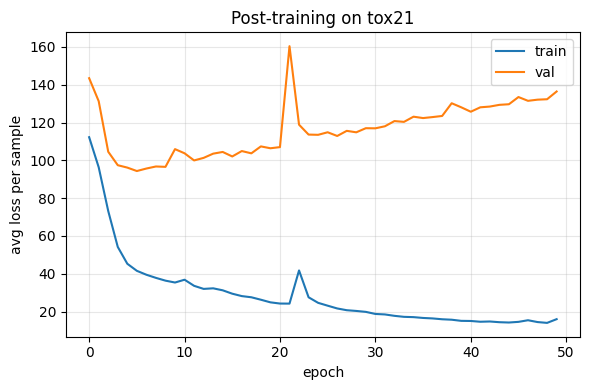

In [43]:
if post_history is not None:
    plt.figure(figsize=(6, 4))
    plt.plot(post_history["train_total"], label="train")
    plt.plot(post_history["val_total"], label="val")
    plt.xlabel("epoch")
    plt.ylabel("avg loss per sample")
    plt.title("Post-training on tox21")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No post-training history to plot yet.")
